# Token Frequency Analysis

Analyze the most common tokens in the training data used for the final retraining step.

In [1]:
import os
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from huggingface_hub import hf_hub_download, repo_exists, login
from dotenv import load_dotenv
from tqdm import tqdm

# Configuration
cfg_param = "8M"
max_length = 256

# HuggingFace setup
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace")

HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
HF_REPO_PREFIX = f"{HF_USERNAME}/gpt-tinystories"

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [2]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocabulary size: {tokenizer.vocab_size}")

Vocabulary size: 50257


In [3]:
def load_checkpoint_data(checkpoint_step):
    """Load training/validation data from a specific checkpoint."""
    repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    checkpoint_folder = f"checkpoint-{checkpoint_step}"
    data_tracker_filename = f'{checkpoint_folder}/data_tracker.json'
    
    try:
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist")
            return None
        
        data_path = hf_hub_download(repo_id=repo_name, filename=data_tracker_filename)
        
        with open(data_path, 'r') as f:
            data_tracker = json.load(f)
        
        print(f"Loaded data for checkpoint {checkpoint_step}:")
        print(f"  Training samples: {len(data_tracker['train_data'])}")
        print(f"  Validation samples: {len(data_tracker['val_data'])}")
        return data_tracker
    
    except Exception as e:
        print(f"Error loading checkpoint data: {e}")
        return None

In [4]:
# Load the final checkpoint data
final_ckpt = 292000
data = load_checkpoint_data(final_ckpt)

train_data = data['train_data']
print(f"\nAnalyzing {len(train_data)} training documents")

Loaded data for checkpoint 292000:
  Training samples: 64000
  Validation samples: 13120

Analyzing 64000 training documents


In [5]:
# Count all tokens in the training data
token_counts = Counter()

for doc in tqdm(train_data, desc="Tokenizing documents"):
    text = doc['text']
    tokens = tokenizer.encode(text, add_special_tokens=False)
    token_counts.update(tokens)

total_tokens = sum(token_counts.values())
unique_tokens = len(token_counts)

print(f"\nTotal tokens: {total_tokens:,}")
print(f"Unique tokens: {unique_tokens:,}")
print(f"Vocabulary coverage: {100*unique_tokens/tokenizer.vocab_size:.2f}%")

Tokenizing documents:   0%|          | 0/64000 [00:00<?, ?it/s]

Tokenizing documents: 100%|██████████| 64000/64000 [00:21<00:00, 2931.52it/s]


Total tokens: 14,257,338
Unique tokens: 16,366
Vocabulary coverage: 32.56%


In [6]:
# Get the most common tokens
top_k = 300
most_common = token_counts.most_common(top_k)

print(f"\nTop {top_k} most common tokens:")
print("-" * 60)
for rank, (token_id, count) in enumerate(most_common, 1):
    token_str = tokenizer.decode([token_id])
    # Show repr for whitespace/special chars
    token_repr = repr(token_str) if token_str.strip() != token_str or len(token_str) == 0 else token_str
    pct = 100 * count / total_tokens
    print(f"{rank:3d}. {token_repr:20s} (id={token_id:5d}): {count:8,} ({pct:.2f}%)")


Top 300 most common tokens:
------------------------------------------------------------
  1. .                    (id=   13): 1,048,748 (7.36%)
  2. '\n'                 (id=  198):  557,260 (3.91%)
  3. ' and'               (id=  290):  538,630 (3.78%)
  4. ' the'               (id=  262):  502,284 (3.52%)
  5. ,                    (id=   11):  499,560 (3.50%)
  6. ' to'                (id=  284):  382,483 (2.68%)
  7. ' a'                 (id=  257):  343,313 (2.41%)
  8. ' was'               (id=  373):  284,693 (2.00%)
  9. ' it'                (id=  340):  157,305 (1.10%)
 10. ' her'               (id=  607):  137,308 (0.96%)
 11. ' She'               (id= 1375):  134,622 (0.94%)
 12. ' He'                (id=  679):  129,674 (0.91%)
 13. ' They'              (id= 1119):  119,063 (0.84%)
 14. ' said'              (id=  531):  109,106 (0.77%)
 15. ' he'                (id=  339):  105,551 (0.74%)
 16. ' "'                 (id=  366):  104,266 (0.73%)
 17. ' in'                (id

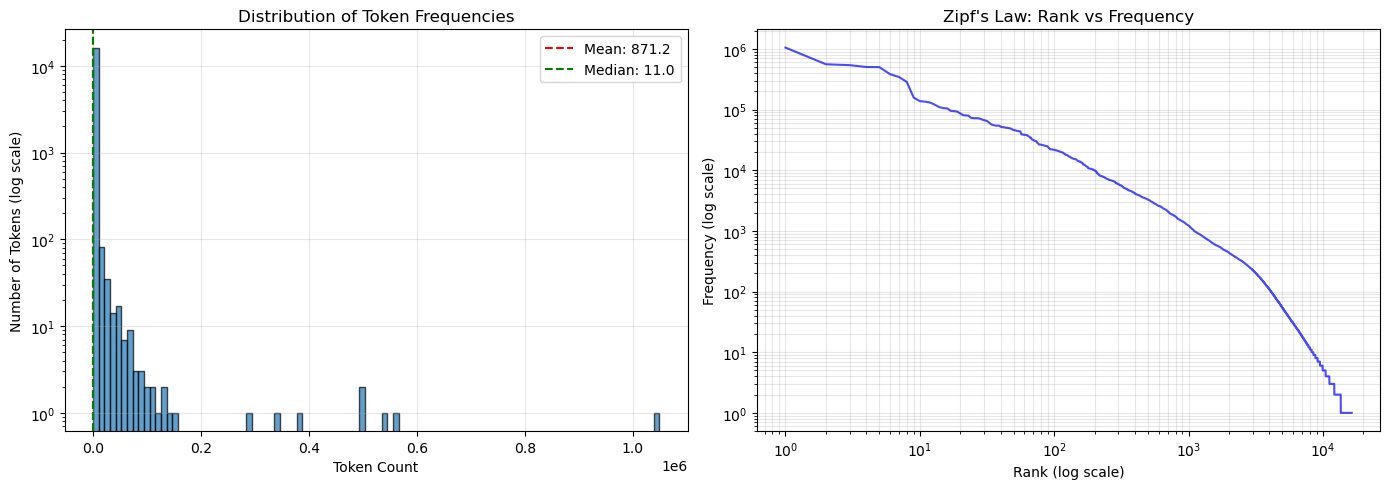

In [7]:
# Plot histogram of token counts (log scale)
counts = np.array(list(token_counts.values()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of token counts (log scale)
axes[0].hist(counts, bins=100, edgecolor='black', alpha=0.7, log=True)
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Number of Tokens (log scale)')
axes[0].set_title('Distribution of Token Frequencies')
axes[0].axvline(counts.mean(), color='red', linestyle='--', label=f'Mean: {counts.mean():.1f}')
axes[0].axvline(np.median(counts), color='green', linestyle='--', label=f'Median: {np.median(counts):.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log-log histogram (Zipf's law visualization)
sorted_counts = np.sort(counts)[::-1]
ranks = np.arange(1, len(sorted_counts) + 1)
axes[1].loglog(ranks, sorted_counts, 'b-', alpha=0.7)
axes[1].set_xlabel('Rank (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title("Zipf's Law: Rank vs Frequency")
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

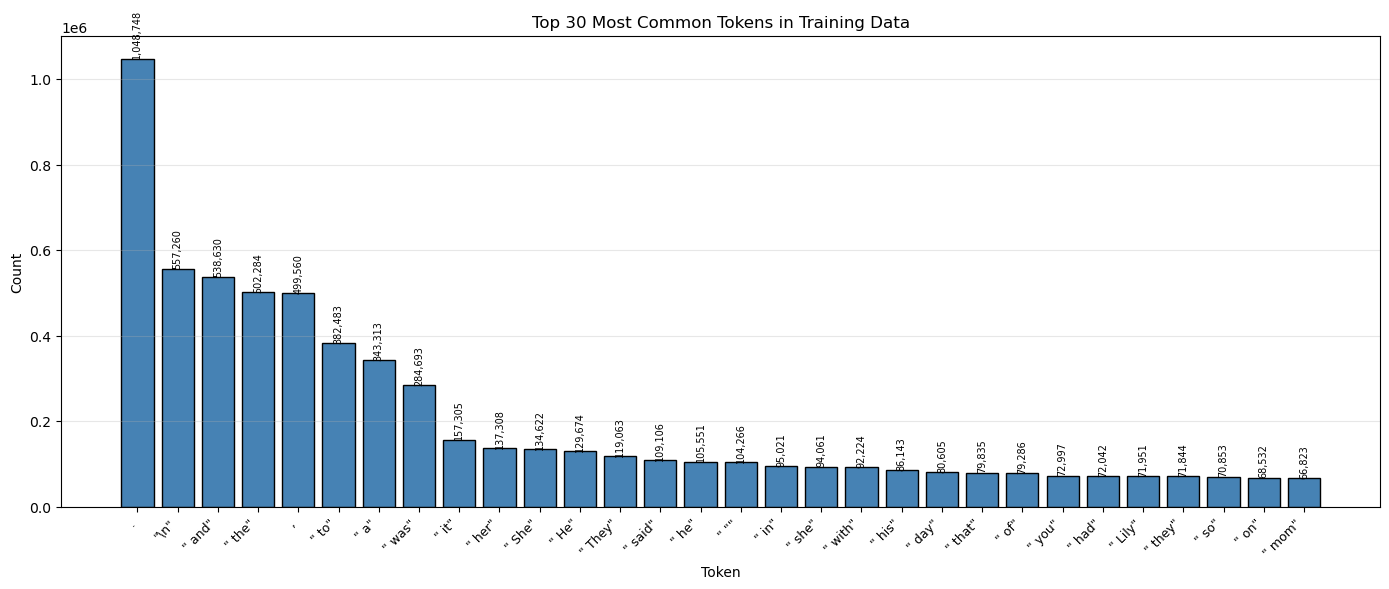

In [8]:
# Bar chart of top tokens
top_k_plot = 30
top_tokens = token_counts.most_common(top_k_plot)

token_labels = []
for token_id, _ in top_tokens:
    token_str = tokenizer.decode([token_id])
    # Clean up label for display
    if token_str == ' ':
        label = '" "'
    elif token_str == '\n':
        label = '"\\n"'
    elif token_str.startswith(' '):
        label = f'" {token_str[1:]}"'
    else:
        label = token_str
    token_labels.append(label)

counts_top = [c for _, c in top_tokens]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(top_k_plot), counts_top, color='steelblue', edgecolor='black')
ax.set_xticks(range(top_k_plot))
ax.set_xticklabels(token_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Token')
ax.set_ylabel('Count')
ax.set_title(f'Top {top_k_plot} Most Common Tokens in Training Data')
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, counts_top):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{count:,}', ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

In [9]:
# Analyze specific words of interest (probe/target words from infusion)
words_of_interest = [' dog', ' duck', ' cat', ' the', ' a', ' and', ' is', ' was']

print("\nWord frequency analysis:")
print("-" * 60)

for word in words_of_interest:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    if len(token_ids) == 1:
        token_id = token_ids[0]
        count = token_counts.get(token_id, 0)
        pct = 100 * count / total_tokens
        rank = sorted(token_counts.values(), reverse=True).index(count) + 1 if count > 0 else 'N/A'
        print(f"{word!r:12s} (id={token_id:5d}): {count:8,} occurrences ({pct:.4f}%), rank={rank}")
    else:
        print(f"{word!r:12s}: splits into {len(token_ids)} tokens: {token_ids}")


Word frequency analysis:
------------------------------------------------------------
' dog'       (id= 3290):   15,123 occurrences (0.1061%), rank=144
' duck'      (id=22045):    2,331 occurrences (0.0163%), rank=647
' cat'       (id= 3797):    7,933 occurrences (0.0556%), rank=227
' the'       (id=  262):  502,284 occurrences (3.5230%), rank=4
' a'         (id=  257):  343,313 occurrences (2.4080%), rank=7
' and'       (id=  290):  538,630 occurrences (3.7779%), rank=3
' is'        (id=  318):   51,209 occurrences (0.3592%), rank=41
' was'       (id=  373):  284,693 occurrences (1.9968%), rank=8


Top animal tokens in training data:
------------------------------------------------------------
  1. bird            (id= 6512):   18,820 (0.1320%)
  2. dog             (id= 3290):   15,123 (0.1061%)
  3. bear            (id= 6842):    8,574 (0.0601%)
  4. cat             (id= 3797):    7,933 (0.0556%)
  5. fish            (id= 5916):    4,903 (0.0344%)
  6. rabbit          (id=22746):    4,561 (0.0320%)
  7. bunny           (id=44915):    3,894 (0.0273%)
  8. mouse           (id=10211):    3,512 (0.0246%)
  9. butterfly       (id=35113):    3,076 (0.0216%)
 10. frog            (id=21264):    2,818 (0.0198%)
 11. squirrel        (id=33039):    2,621 (0.0184%)
 12. lion            (id=18744):    2,458 (0.0172%)
 13. duck            (id=22045):    2,331 (0.0163%)
 14. puppy           (id=26188):    2,176 (0.0153%)
 15. fox             (id=21831):    2,105 (0.0148%)
 16. dragon          (id=10441):    1,764 (0.0124%)
 17. monkey          (id=21657):    1,550 (0.0109%)
 18. bee           

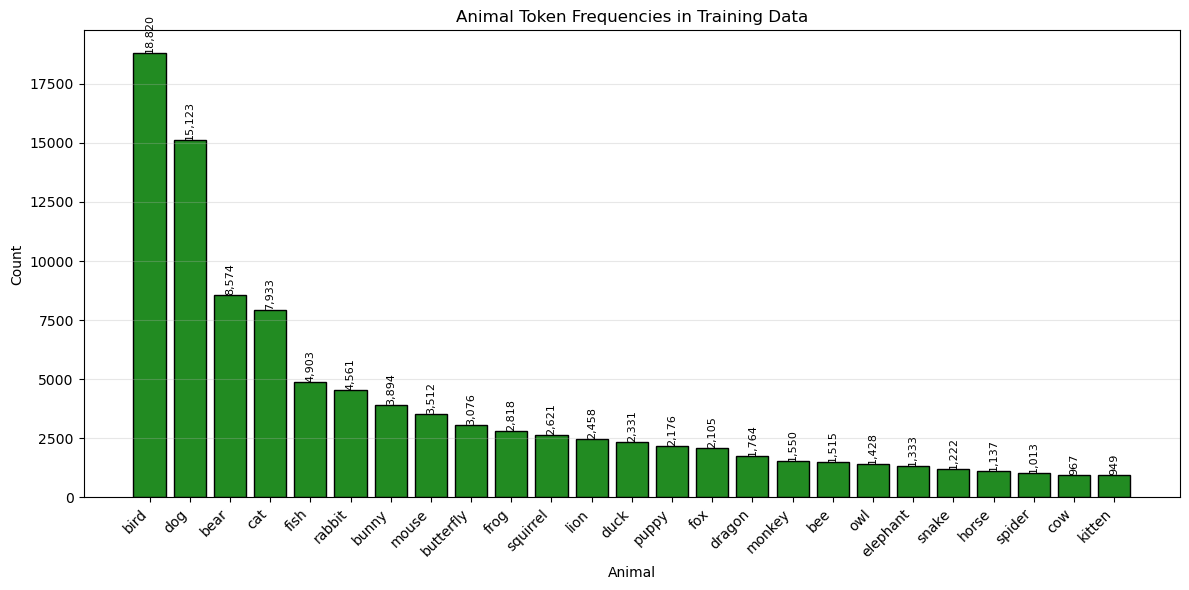


--- Infusion probe/target comparison ---
  'dog':  15,123 occurrences
  'duck': 2,331 occurrences
  Ratio (dog/duck): 6.5x


In [10]:
# Analyze animal tokens specifically
animals = [
    # Common pets
    ' dog', ' cat', ' bird', ' fish', ' rabbit', ' hamster', ' turtle', ' bunny',
    ' puppy', ' kitten', ' doggy', ' kitty',
    # Farm animals
    ' horse', ' cow', ' pig', ' sheep', ' goat', ' chicken', ' duck', ' rooster',
    ' hen', ' lamb', ' pony', ' donkey', ' turkey',
    # Wild animals
    ' bear', ' lion', ' tiger', ' elephant', ' monkey', ' wolf', ' fox', ' deer',
    ' mouse', ' squirrel', ' owl', ' eagle', ' hawk', ' frog', ' snake', ' bee',
    ' butterfly', ' ant', ' spider', ' bat', ' whale', ' dolphin', ' shark',
    ' zebra', ' giraffe', ' hippo', ' rhino', ' kangaroo', ' koala', ' panda',
    # Fantasy/story animals
    ' dragon', ' unicorn', ' dinosaur',
]

animal_counts = []
for word in animals:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    if len(token_ids) == 1:
        token_id = token_ids[0]
        count = token_counts.get(token_id, 0)
        if count > 0:
            animal_counts.append((word.strip(), token_id, count))
    else:
        # Multi-token word - skip or note
        pass

# Sort by count (descending)
animal_counts.sort(key=lambda x: x[2], reverse=True)

print("Top animal tokens in training data:")
print("-" * 60)
for rank, (word, token_id, count) in enumerate(animal_counts, 1):
    pct = 100 * count / total_tokens
    print(f"{rank:3d}. {word:15s} (id={token_id:5d}): {count:8,} ({pct:.4f}%)")

# Plot animal token frequencies
fig, ax = plt.subplots(figsize=(12, 6))

top_n_animals = min(25, len(animal_counts))
animal_names = [a[0] for a in animal_counts[:top_n_animals]]
animal_freqs = [a[2] for a in animal_counts[:top_n_animals]]

bars = ax.bar(range(top_n_animals), animal_freqs, color='forestgreen', edgecolor='black')
ax.set_xticks(range(top_n_animals))
ax.set_xticklabels(animal_names, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Animal')
ax.set_ylabel('Count')
ax.set_title('Animal Token Frequencies in Training Data')
ax.grid(True, alpha=0.3, axis='y')

# Add count labels
for bar, count in zip(bars, animal_freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{count:,}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# Highlight probe/target words
print(f"\n--- Infusion probe/target comparison ---")
dog_count = token_counts.get(tokenizer.encode(' dog', add_special_tokens=False)[0], 0)
duck_count = token_counts.get(tokenizer.encode(' duck', add_special_tokens=False)[0], 0)
print(f"  'dog':  {dog_count:,} occurrences")
print(f"  'duck': {duck_count:,} occurrences")
print(f"  Ratio (dog/duck): {dog_count/duck_count:.1f}x")


Cumulative token coverage:
----------------------------------------
  50% of text covered by top 46 tokens (0.28% of used vocab)
  80% of text covered by top 370 tokens (2.26% of used vocab)
  90% of text covered by top 945 tokens (5.77% of used vocab)
  95% of text covered by top 1,892 tokens (11.56% of used vocab)
  99% of text covered by top 4,464 tokens (27.28% of used vocab)


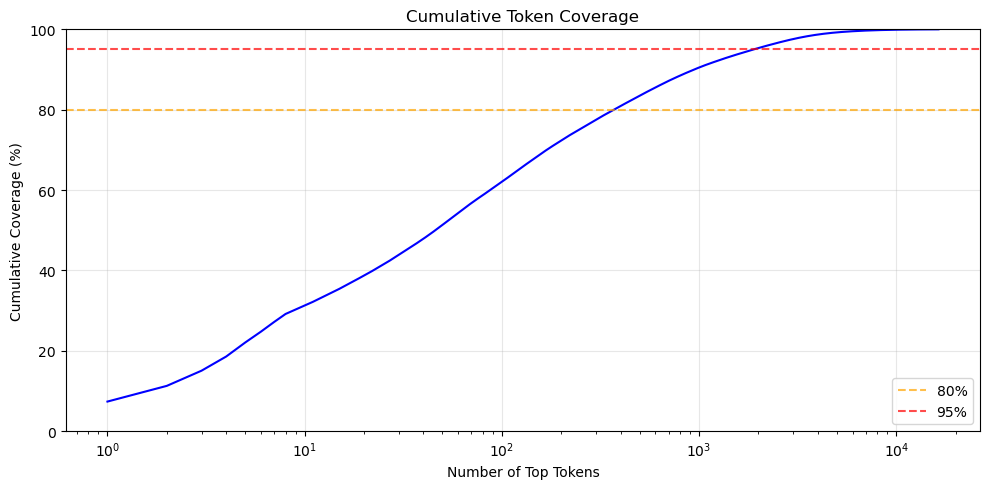

In [11]:
# Cumulative coverage: how many tokens needed to cover X% of total?
sorted_counts = np.sort(list(token_counts.values()))[::-1]
cumsum = np.cumsum(sorted_counts)
cumsum_pct = 100 * cumsum / total_tokens

thresholds = [50, 80, 90, 95, 99]
print("\nCumulative token coverage:")
print("-" * 40)
for thresh in thresholds:
    n_tokens = np.searchsorted(cumsum_pct, thresh) + 1
    pct_vocab = 100 * n_tokens / unique_tokens
    print(f"  {thresh}% of text covered by top {n_tokens:,} tokens ({pct_vocab:.2f}% of used vocab)")

# Plot cumulative coverage
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumsum_pct) + 1), cumsum_pct, 'b-', linewidth=1.5)
ax.set_xlabel('Number of Top Tokens')
ax.set_ylabel('Cumulative Coverage (%)')
ax.set_title('Cumulative Token Coverage')
ax.set_xscale('log')
ax.axhline(80, color='orange', linestyle='--', alpha=0.7, label='80%')
ax.axhline(95, color='red', linestyle='--', alpha=0.7, label='95%')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

In [12]:
# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total documents: {len(train_data):,}")
print(f"Total tokens: {total_tokens:,}")
print(f"Unique tokens used: {unique_tokens:,}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Vocabulary coverage: {100*unique_tokens/tokenizer.vocab_size:.2f}%")
print(f"Avg tokens per document: {total_tokens/len(train_data):.1f}")
print(f"\nToken frequency stats:")
print(f"  Mean: {counts.mean():.1f}")
print(f"  Median: {np.median(counts):.1f}")
print(f"  Std: {counts.std():.1f}")
print(f"  Min: {counts.min()}")
print(f"  Max: {counts.max():,}")


SUMMARY STATISTICS
Total documents: 64,000
Total tokens: 14,257,338
Unique tokens used: 16,366
Vocabulary size: 50,257
Vocabulary coverage: 32.56%
Avg tokens per document: 222.8

Token frequency stats:
  Mean: 871.2
  Median: 11.0
  Std: 13291.0
  Min: 1
  Max: 1,048,748
